In [1]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt

base_path = r"/Users/leo/LeoData/MyCode/KoreaITAcademy/LangChain/dataset/ComputerVision/01"

def cv2_imshow(image):
    cv2.imshow('image', image)
    cv2.waitKey(0)
    cv2.destroyAllWindows()
    for _ in range(5):
        cv2.waitKey(1)

def plt_imshow(image, axis=True):  # OpenCV 이미지를 matplotlib 으로 출력하기
    img = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    plt.axis(axis)
    plt.show()    


# 이미지 처리(Image Processing)

## Resize

- `cv2.resize()`
  - 사이즈가 변하면 pixel사이의 값을 결정을 해야함
  
  - 보간법(Interpolation method)
    - 사이즈를 줄일 때 : `cv2.INTER_AREA` 
    
    - 사이즈를 크게 할 때 : `cv2.INTER_CUBIC` , `cv2.INTER_LINEAR`

  - `Parameters`
    - `img` : Image

    - `dsize` : Manual Size. 가로, 세로 형태의 tuple(ex; (100,200))

    - `fx` : 가로 사이즈의 배수. 2배로 크게하려면 2. 반으로 줄이려면 0.5

    - `fy` : 세로 사이즈의 배수

    - `interpolation` : 보간법


In [7]:
image = cv2.imread(os.path.join(base_path, 'Lenna.png'))
image.shape

(512, 512, 3)

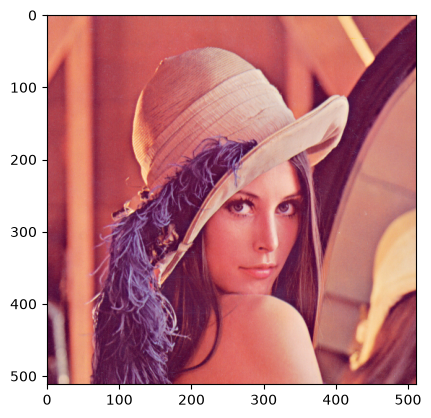

In [8]:
plt_imshow(image)

In [9]:
heigth, width = image.shape[:2]
heigth, width

(512, 512)

(256, 256, 3)


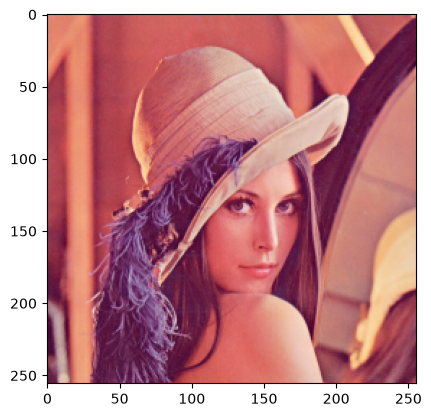

(256, 256, 3)


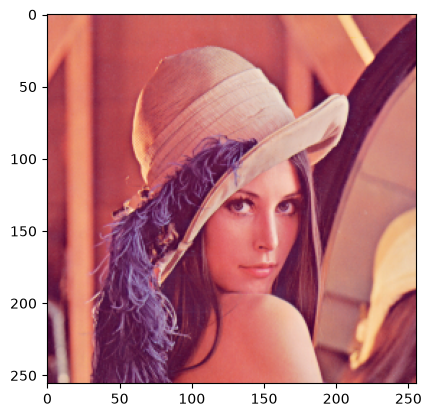

In [12]:
# 1/2 로 줄이기
shrink = cv2.resize(src=image, dsize=None, fx=0.5, fy=0.5)
print(shrink.shape)
plt_imshow(shrink)

shrink = cv2.resize(src=image, dsize=None, fx=0.5, fy=0.5, interpolation=cv2.INTER_AREA)
print(shrink.shape)
plt_imshow(shrink)

(1024, 1024, 3)


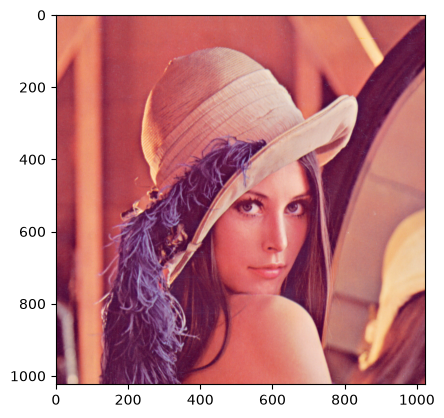

(1024, 1024, 3)


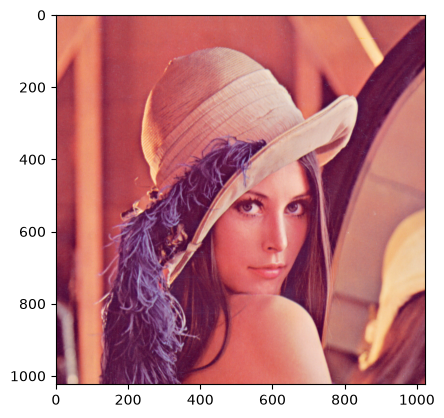

In [15]:
# x2 늘리기
expand1 = cv2.resize(src=image, dsize=None, fx=2, fy=2, interpolation=cv2.INTER_AREA)
print(expand1.shape)
plt_imshow(expand1)

expand1 = cv2.resize(src=image, dsize=(width * 2, heigth * 2), interpolation=cv2.INTER_AREA)
print(expand1.shape)
plt_imshow(expand1)

## Translation

- 이미지의 '위치'를 변경

- `cv2.warpAffine()`

  - `Parameters` 
    - `src` : Image
    
    - `M` : 변환 행렬 (2x3 행렬)

    - `dsize` (tuple) : output image size(ex; (width=columns, height=rows)



In [16]:
rows, cols = image.shape[:2]
rows, cols

(512, 512)

In [17]:
# 변환 행렬 준비
M = np.float32([
    [1, 0, 10],  # x축으로 10 이동(오른쪽)
    [0, 1, 20],  # y축으로 20 이동(왼쪽)
])

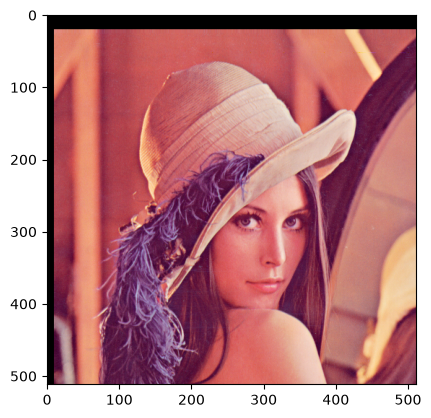

In [19]:
dst = cv2.warpAffine(src=image, M=M, dsize=(cols, rows))
plt_imshow(dst)

## Rotate

- 물체를 평면상의 한 점을 중심으로 𝜃 만큼 회전하는 변환

- 양(+)의 각도는 시계반대방향으로 회전

- `cv2.getRotationMatrix2D()`
  
  - `Parameters`  	

    - `center` : 이미지의 중심 좌표
    
    - `angle` : 회전 각도

    - `scale` : scale factor
  - `Return`
    -  변환행렬


In [21]:
# 이미지의 '중심'을 기준으로 60도 회전하기
#  이를 위한 변환 행렬(2x3) 생성
M = cv2.getRotationMatrix2D(center=(cols / 2, rows / 2), angle=60, scale=0.5)
M

array([[ 2.50000000e-01,  4.33012702e-01,  8.11487483e+01],
       [-4.33012702e-01,  2.50000000e-01,  3.02851252e+02]])

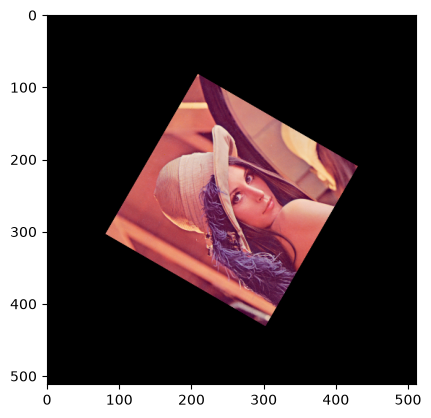

In [22]:
dst = cv2.warpAffine(image, M, (cols, rows))
plt_imshow(dst)

## Flip

- 대칭 변환
  - 좌우 대칭 (좌우 반전)

  - 상하 대칭 (상하 반전)

- 입력 영상과 출력 영상의 픽셀이 1:1 매칭이므로 보간법이 필요 없음

- `cv2.flip()`

  - Parameters

    - `src` : 입력 영상

    - `flipCode` : 대칭 방법을 결정하는 flag 인자

      - 양수이면 좌우 대칭

      - 0이면 상하 대칭

      - 음수이면 상하, 좌우 대칭을 모두 실행


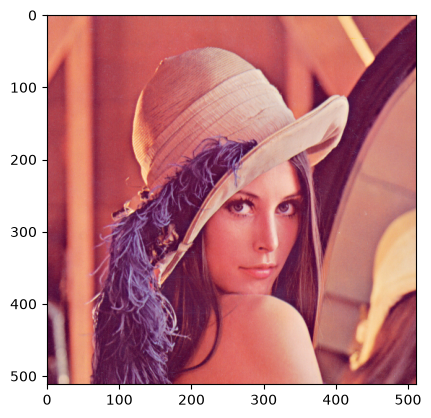

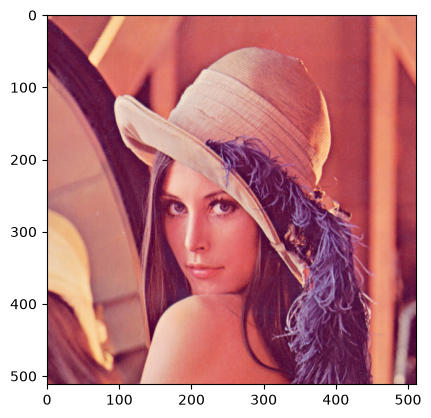

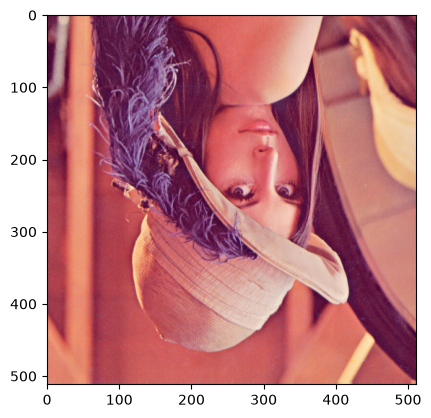

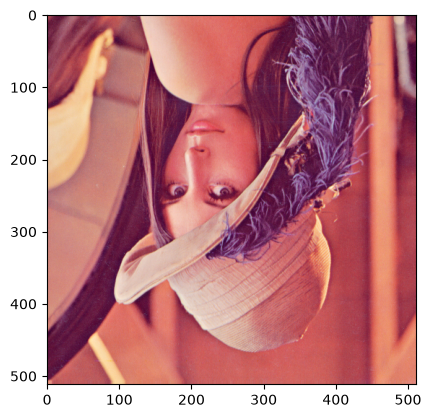

In [26]:
plt_imshow(image)

plt_imshow(cv2.flip(src=image, flipCode=1))  # 좌우 flip (어떤 양수값이라도 무관)
plt_imshow(cv2.flip(src=image, flipCode=0))  # 상하 flip
plt_imshow(cv2.flip(src=image, flipCode=-1)) # 상하 & 좌우 flip (어떤 음수값이라도 무관)

## Affine Transformation

- 선의 평행선은 유지되면서 이미지를 변환하는 작업

- 이동, 확대, Scale, 반전까지 포함된 변환

- `cv2.getAffineTransform()`

  - Affine 변환을 위해서는 3개의 Match가 되는 점이 있으면 변환행렬을 구할 수 있음


In [36]:
# 3개의 점 세트를 2개 준비
# getAffineTransform 에 전달한 값들
# [가로 cols, 세로 rows] 로 사용될겂임! (주의!)

pts1 = np.float32([[200, 100], [400, 100], [200, 200],])
pts2 = np.float32([[200, 300], [400, 200], [200, 400],])


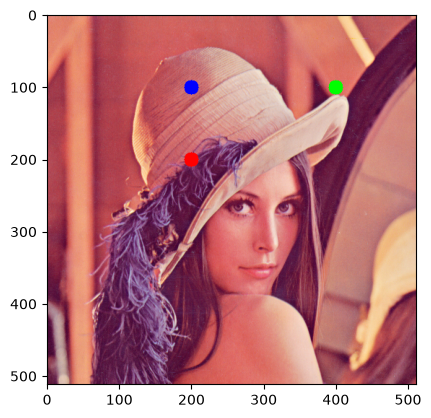

In [37]:
# 일단 pts1 점을 찍어보자
cv2.circle(image, center=(200, 100), radius=10, color=(255,0,0), thickness=-1)
cv2.circle(image, center=(400, 100), radius=10, color=(0,255,0), thickness=-1)
cv2.circle(image, center=(200, 200), radius=10, color=(0,0,255), thickness=-1)

plt_imshow(image)

In [38]:
# pts1 -> pts2 로 변환하는 변환행렬 구하기
M = cv2.getAffineTransform(pts1, pts2)
M

array([[  1. ,   0. ,   0. ],
       [ -0.5,   1. , 300. ]])

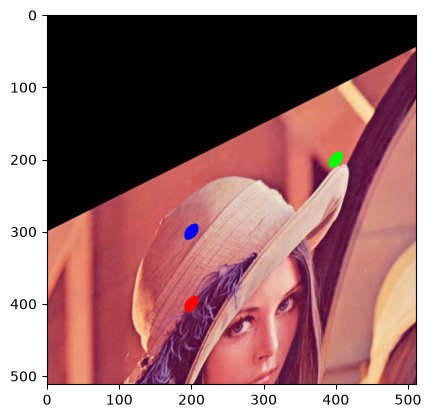

In [39]:
dst = cv2.warpAffine(image, M, (cols, rows))
plt_imshow(dst)

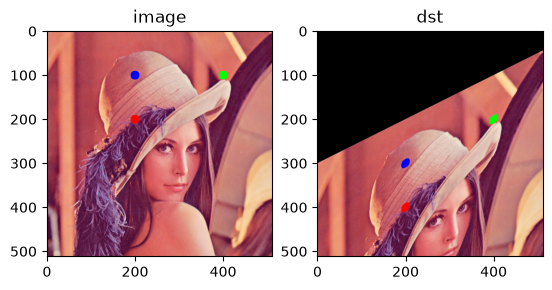

In [41]:
fig, (ax1, ax2) = plt.subplots(1, 2)

ax1.imshow(image[..., ::-1])
ax1.set_title('image')
ax2.imshow(dst[..., ::-1])
ax2.set_title('dst')
plt.show()

## Perspective Transformation

- Perspective(원근법) 변환

- 직선의 성질만 유지, 선의 평행성은 유지가 되지 않는 변환

- 기차길은 서로 평행하지만 원근변환을 거치면 평행성은 유지 되지 못하고 하나의 점에서 만나는 것 처럼 보임 (반대의 변환도 가능)

- 4개의 Point의 Input값과 이동할 output Point 가 필요

- `cv2.getPerspectiveTransform()`가 필요하며, `cv2.warpPerspective()` 함수에 변환행렬값을 적용하여 최종 결과 이미지를 얻을 수 있음


(640, 428, 3)


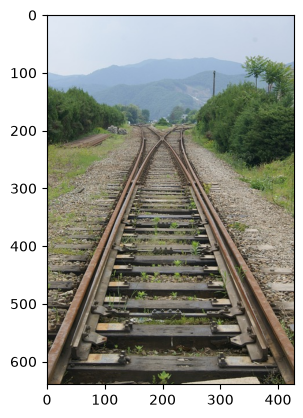

In [42]:
train = cv2.imread(os.path.join(base_path, 'train.jpg'))
print(train.shape)
plt_imshow(train)

In [52]:
# 개의 좌표점 준비: `왼쪽 위 -> 오른쪽 위 -> 오른쪽 아래 -> 왼쪽 아래` 순서

top_left = (130, 300)
top_right = (270, 300)
bottom_right = (400, 550)
bottom_left = (30, 550)

pts1 = np.float32([top_left, top_right, bottom_right, bottom_left])

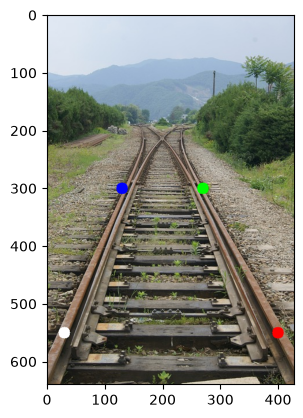

In [53]:
cv2.circle(train, top_left, 10, (255, 0, 0), -1)
cv2.circle(train, top_right, 10, (0, 255, 0), -1)
cv2.circle(train, bottom_right, 10, (0, 0, 255), -1)
cv2.circle(train, bottom_left, 10, (255, 255, 255), -1)

plt_imshow(train)

In [54]:
# pts2 계산을 위해
# width, height 계산

w1 = abs(bottom_right[0] - bottom_left[0])
w2 = abs(top_right[0] - top_left[0])
h1 = abs(top_right[1] - bottom_right[1])
h2 = abs(top_left[1] - bottom_left[1])

max_width = max([w1, w2])
max_height = max([h1, h2])

pts2 = np.float32([
    [0, 0],
    [max_width-1, 0],
    [max_width-1, max_height-1],
    [0, max_height-1],
])

pts2

array([[  0.,   0.],
       [369.,   0.],
       [369., 249.],
       [  0., 249.]], dtype=float32)

In [55]:
# 변환행렬 생성
M = cv2.getPerspectiveTransform(src=pts1, dst=pts2)
M  # (3, 3)

array([[-2.71323529e+00, -1.08529412e+00,  6.78308824e+02],
       [ 1.94991592e-16, -2.70970588e+00,  8.12911765e+02],
       [ 1.13395846e-18, -6.76470588e-03,  1.00000000e+00]])

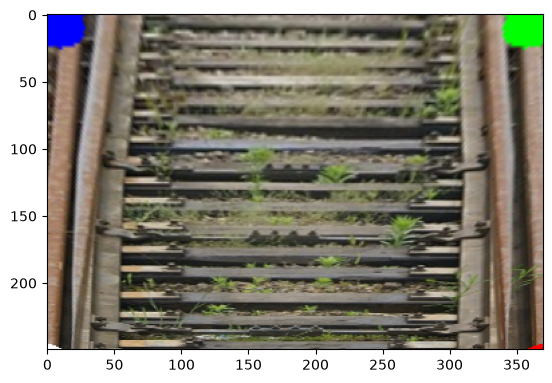

In [56]:
dst = cv2.warpPerspective(train, M, (max_width, max_height))
plt_imshow(dst)

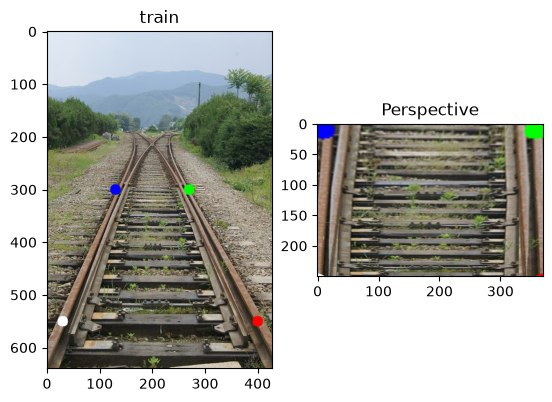

In [57]:
fig, (ax1, ax2) = plt.subplots(1, 2)

ax1.imshow(train[..., ::-1])
ax1.set_title('train')
ax2.imshow(dst[..., ::-1])
ax2.set_title('Perspective')
plt.show()

In [ ]:
# ※ OCR 등의 문자 인식에서 이와 같은 변형을 사전에 해주어야 할 필요가 있다.
# ※ OCR 등의 문자 인식 (객체 인식) 을 수행하기 위해선 위와 같은 변형을 사전에 해주어야 한다